In [42]:
%cd /mlx_devbox/users/janne.spijkervet/repo/333/samantha/
%load_ext autoreload
%autoreload 2

# SoundStorm



We design our masking scheme for training accordingly. To enable voice prompting, we randomly sample a timestep t ∈ {1, . . . , T}, where T denotes the maximum sequence length, and we do not mask any tokens before this timestep. The conditioning tokens are never masked. Let Y ∈ {1, . . . , C} T ×Q denote the SoundStream tokens, where C indicates the codebook size used in each RVQ level out of the Q levels. Our masking scheme proceeds as follows:

- Sample the prompt delimiter timestep t ∼ U{0, T −1};
- Sample the current RVQ level q ∼ U{1, Q}
- Sample the mask M ∈ {0, 1}T according to a cosine schedule (Chang et al., 2022) for level q, i.e., sample the masking ratio p = cos(u) where u ∼ U [0, π/2], and sample iid Mi ∼ Bernoulli(p).
- Mask the selected non-prompt tokens at the current RVQ level q (maskYt′,q ifMt′ =1andt′ >t)andall non-prompt tokens at finer RVQ levels (Y>t,>q ).

# Data

We can create some test data by running:

```bash
python3 ./recipes/soundstorm/tests/create_test_dataset.py 
```

In [43]:
import torch
import webdataset as wds
import IPython.display as ipd

batch_size = 4
dataset = wds.WebDataset(
    urls="pipe:hdfs dfs -cat hdfs://harunava/home/byte_speech_sv/data/karaoke_for_singsong/test_dataset.tar",
)
dataset = (dataset
    .shuffle(100)
    .decode()
    .to_tuple("semantic_tokens.npy audio_tokens.npy audio.npy")
    .batched(batch_size)
)


seq_len = 100

for idx, batch in enumerate(dataset):
    if idx == 1:
        break
        
    semantic_tokens, audio_tokens, audio = batch
    semantic_tokens = torch.from_numpy(semantic_tokens[..., :seq_len//2])
    audio_tokens = torch.from_numpy(audio_tokens[..., :seq_len])
    ipd.display(ipd.Audio(audio[0], rate=24000))


SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/opt/tiger/yarn_deploy/hadoop-2.6.0-cdh5.4.4/share/hadoop/common/lib/zti-jwt-helper-java-1.0.8.jar!/org/byted/security/zti/jwt/shaded/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/opt/tiger/yarn_deploy/hadoop-2.6.0-cdh5.4.4/share/hadoop/common/lib/zti-jwt-java-1.0.16.jar!/org/byted/security/zti/jwt/shaded/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.byted.security.zti.jwt.shaded.org.slf4j.helpers.NOPLoggerFactory]


''

''

# Batch composition

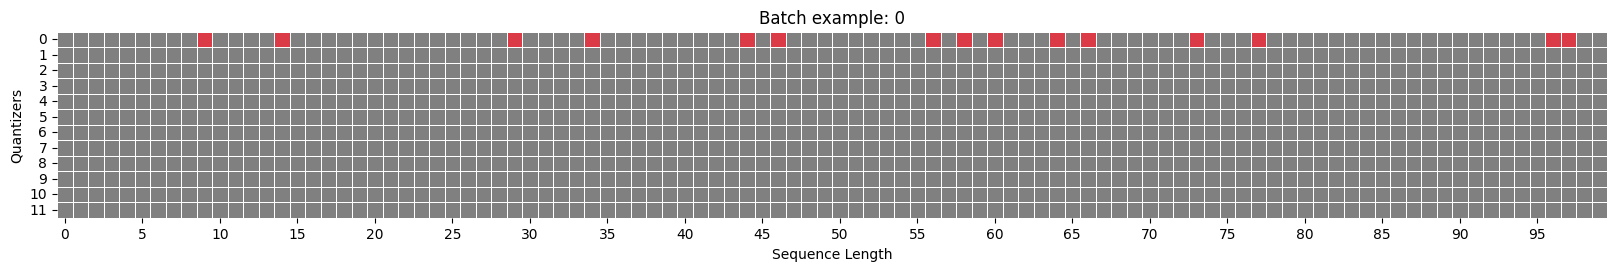

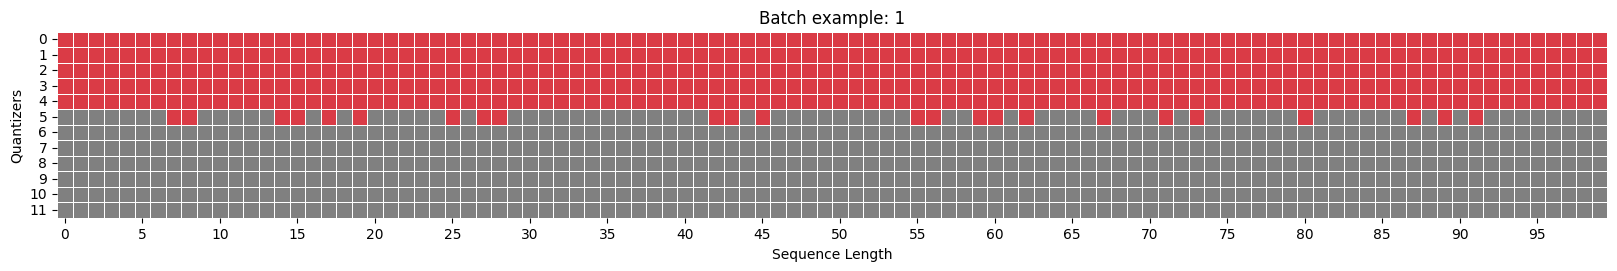

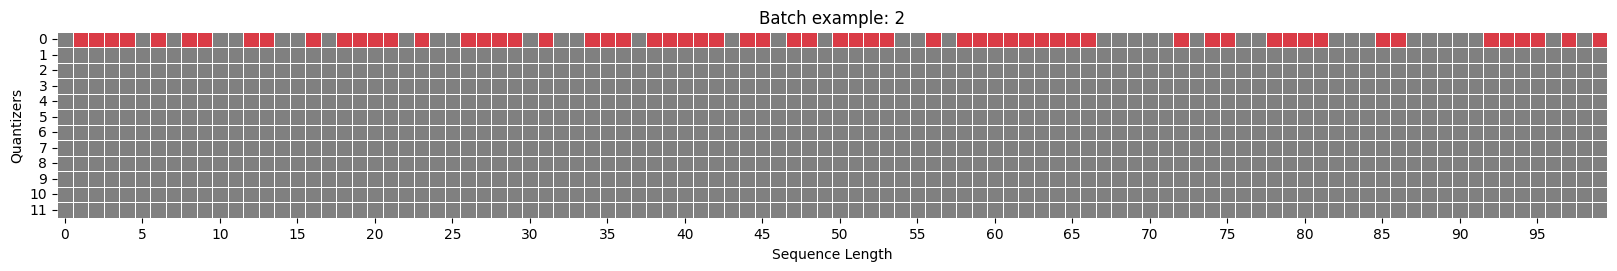

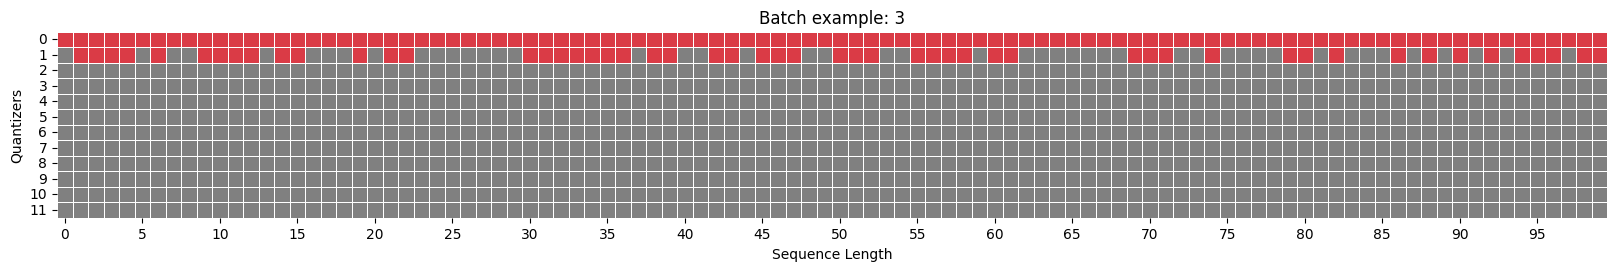

In [44]:
!pip3 install -q seaborn
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from recipes.soundstorm.lightning.soundstorm import masking_scheme

cmap = sns.diverging_palette(220, 10, as_cmap=True)
cmap.set_bad("gray")


# audio_tokens = torch.randint(0, 1024, size=(batch_size, n_quantizers, seq_len))
masked, mask, rand_qs = masking_scheme(audio_tokens[..., :seq_len], 1024, sample_q_uniformly=False, sample_t=False)
# masked, mask = maskgit_masking_scheme(audio_tokens[..., :seq_len], 1024)

masked[masked == 1024] = -1
masked[masked != -1] = 1


for idx in range(masked.shape[0]):
    fig = plt.figure(figsize=(20,8))
    ax = sns.heatmap(masked[idx].cpu(), mask=(masked[idx] == -1).cpu().numpy(), cmap=cmap, vmin=-1, vmax=1, square=True, xticklabels=5, yticklabels=1, linewidths=.5, cbar=False)
    ax.grid(False)
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel("Quantizers")
    ax.set_title(f"Batch example: {idx}")
    plt.show()

In [45]:
from recipes.soundstorm.lightning.soundstorm import masking_scheme
from collections import Counter

def counts(sample_q_uniformly):
    c = Counter()
    c_mask = Counter()
    for _ in range(1000):
        _, mask, rand_qs = masking_scheme(audio_tokens, 1024, sample_q_uniformly=sample_q_uniformly)
        for batch_idx, rq in enumerate(rand_qs):
            c[rq.item()] += 1
            c_mask[rq.item()] +=  mask[batch_idx, rq].sum().item()
    return c, c_mask

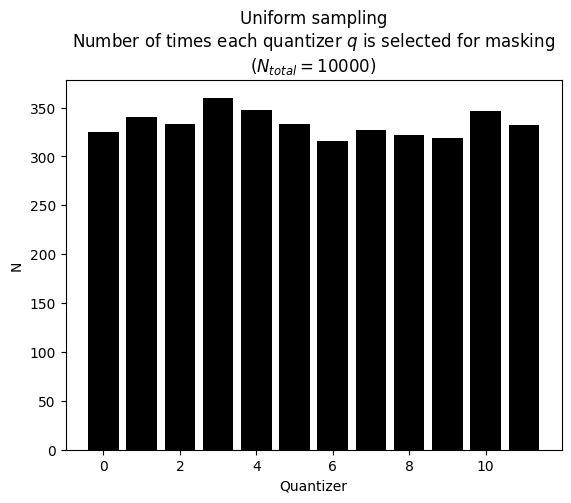

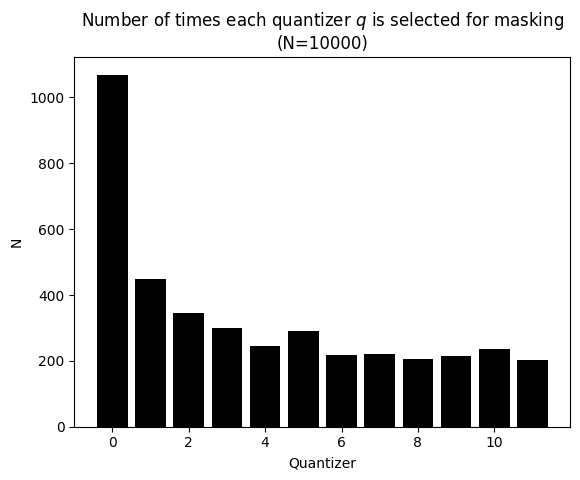

In [46]:
c, c_mask = counts(sample_q_uniformly=True)
plt.bar(c.keys(), c.values(), color="black")
plt.xlabel("Quantizer")
plt.ylabel("N")
plt.title("Uniform sampling\nNumber of times each quantizer $q$ is selected for masking\n($N_{total}=10000$)")
plt.show()

c, c_mask = counts(sample_q_uniformly=False)
plt.bar(c.keys(), c.values(), color="black")
plt.xlabel("Quantizer")
plt.ylabel("N")
plt.title("Number of times each quantizer $q$ is selected for masking\n(N=10000)")
plt.show()

In [47]:
def plot_audio_tokens(at, mask_token_id, q, step_idx, annot):
    
    mask = at == mask_token_id
    fig = plt.figure(figsize=(30, 30), dpi=200)
    
    if mask.sum():
        mask = mask[0, :q+1].numpy()
    else:
        mask = None
    ax = sns.heatmap(at[0, :q+1], mask=mask, cmap=cmap, vmin=-1, vmax=1, square=True, xticklabels=5, yticklabels=1, linewidths=.5, cbar=False, annot=annot, fmt='g')

    ax.grid(False)
    ax.set_title(f"Quantizer: {q}, Step: {step_idx}")

    plt.tight_layout()
    # plt.savefig(f"q-{q}-step-{step_idx}.png")
    plt.show()

## Training

Let's go through the forward pass of the model. The audio tokens need to be masked, while the semantic tokens remain untouched:


In [ ]:
from recipes.soundstorm.lightning.soundstorm import SoundStorm

soundstorm = SoundStorm(24000, n_embd=32, n_layer=2, n_head=2, conv_kernel_size=5, sample_q_uniformly=False, audio_prompting=False, n_audio_samples=48000, optimizer_class=None, scheduler_class=None)

masked_audio_tokens, _, rand_qs = masking_scheme(
    audio_tokens, mask_token_id=soundstorm.mask_token_id
)
logits = soundstorm.forward(semantic_tokens, masked_audio_tokens)

''

ModuleNotFoundError: No module named 'recipes'

We only want to compute the loss on the q'th token, so let's select them:

In [ ]:
print("Sampled q's in batch:", rand_qs)

batch_indices = torch.arange(rand_qs.shape[0])
mask = masked_audio_tokens[batch_indices, rand_qs] == soundstorm.mask_token_id
logits_q = logits[batch_indices, rand_qs]
targets = audio_tokens[batch_indices, rand_qs]


plot_audio_tokens(masked_audio_tokens[0:1], soundstorm.mask_token_id, rand_qs[0], "", True)
plot_audio_tokens(audio_tokens[0:1], soundstorm.mask_token_id, rand_qs[0], "", True)
print(targets[mask])

Finally, we want to compute the cross entropy only on the masked tokens at the $q$'th level:

In [ ]:
import torch.nn.functional as F

logits_q_masked = logits_q[mask]
targets_masked = targets[mask]

loss = F.cross_entropy(logits_q_masked, targets_masked)
print(loss)

## Iterative Decoding

### Cosine Schedule

In [ ]:
import matplotlib.pyplot as plt
from recipes.soundstorm.lightning.soundstorm import cosine_schedule

n_steps = 16
ratios = torch.linspace(0, 1.0, n_steps)[1:]
cos_ratios = cosine_schedule(ratios)
plt.plot(cos_ratios, label="$cos(i)$", color="red", linestyle="-")
plt.title("Cosine sampling schedule")
plt.legend()
plt.show()

In [ ]:
%autoreload 2
from recipes.soundstorm.lightning.soundstorm import SoundStorm

batch_size = 1
semantic_seq_len = 25
semantic_tokens = torch.randint(0, 1024, size=(batch_size, semantic_seq_len), device=soundstorm.device)

iterations = [16, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

sampled_t = 0
audio_tokens, metrics = soundstorm.iterative_decoding(semantic_tokens, semantic_seq_len*2, iterations=iterations, sampled_t=sampled_t)
for step_idx, at in enumerate(metrics["audio_tokens"]):
    plot_audio_tokens(at, soundstorm.mask_token_id, q=0, step_idx=step_idx, annot=True)

## Inference

In [ ]:
import webdataset as wds
import torch
from recipes.soundstorm.lightning.soundstorm import SoundStorm

device = "cuda"

ckpt_path = "epoch=0-step=124000.ckpt"
soundstorm = SoundStorm.load_from_checkpoint(ckpt_path, n_audio_samples=240000).to(device)

''

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:8                                                                                    │
│                                                                                                  │
│   5 device = "cuda"                                                                              │
│   6                                                                                              │
│   7 ckpt_path = "2786011/output/soundstorm/baseline/checkpoints/epoch=0-step=89000.ckpt"         │
│ ❱ 8 soundstorm = SoundStorm.load_from_checkpoint(ckpt_path, n_audio_samples=240000).to(devic     │
│   9                                                                                              │
│                                                                                                  │
│ /usr/local/lib/python3.9/dist-packages/lightning_fabric/utilities/device_dtype_mixin.py:54 in to │
│                                                                                                  │
│    51 │   │   # this converts `str` device to `torch.device`                                     │
│    52 │   │   device, dtype = torch._C._nn._parse_to(*args, **kwargs)[:2]                        │
│    53 │   │   self.__update_properties(device=device, dtype=dtype)                               │
│ ❱  54 │   │   return super().to(*args, **kwargs)                                                 │
│    55 │                                                                                          │
│    56 │   def cuda(self, device: Optional[Union[torch.device, int]] = None) -> Self:             │
│    57 │   │   """Moves all model parameters and buffers to the GPU. This also makes associated   │
│                                                                                                  │
│ /usr/local/lib/python3.9/dist-packages/torch/nn/modules/module.py:1145 in to                     │
│                                                                                                  │
│   1142 │   │   │   │   │   │   │   non_blocking, memory_format=convert_to_format)                │
│   1143 │   │   │   return t.to(device, dtype if t.is_floating_point() or t.is_complex() else No  │
│   1144 │   │                                                                                     │
│ ❱ 1145 │   │   return self._apply(convert)                                                       │
│   1146 │                                                                                         │
│   1147 │   def register_full_backward_pre_hook(                                                  │
│   1148 │   │   self,                                                                             │
│                                                                                                  │
│ /usr/local/lib/python3.9/dist-packages/torch/nn/modules/module.py:797 in _apply                  │
│                                                                                                  │
│    794 │                                                                                         │
│    795 │   def _apply(self, fn):                                                                 │
│    796 │   │   for module in self.children():                                                    │
│ ❱  797 │   │   │   module._apply(fn)                                                             │
│    798 │   │                                                                                     │
│    799 │   │   def compute_should_use_set_data(tensor, tensor_applied):                          │
│    800 │   │   │   if torch._has_compatible_shallow_copy_type(tensor, tensor_applied):           │
│                                                                                                  │
│ /usr/local/lib/python3.9/dist-packages/torch/nn/modules/mod

## Forward pass

In [ ]:
batch = next(iter(dataset))
semantic_tokens, audio_tokens, audio = list(
    map(lambda a: torch.from_numpy(a).to(device), batch)
)

semantic_tokens = semantic_tokens[:1]
audio_tokens = audio_tokens[:1]
audio = audio[:1]

In [ ]:
ipd.display(ipd.Audio(audio[0, :, :soundstorm.hparams.n_audio_samples].cpu(), rate=soundstorm.hparams.sample_rate))

n_audio_frames = (
    soundstorm.hparams.n_audio_samples // soundstorm.hparams.sample_rate
) * soundstorm.audio_model.frame_rate
audio_tokens = audio_tokens[..., :n_audio_frames]
semantic_tokens = semantic_tokens[
    ..., : n_audio_frames // soundstorm.semantic_to_audio_rate
]

masked_audio_tokens, _, rand_qs = masking_scheme(
            audio_tokens, mask_token_id=soundstorm.mask_token_id
)

# plot_audio_tokens(masked_audio_tokens.cpu(), soundstorm.mask_token_id, soundstorm.n_quantizers, "", True)
# plot_audio_tokens(audio_tokens.cpu(), soundstorm.mask_token_id, soundstorm.n_quantizers, "", True)

In [ ]:
logits = soundstorm.forward(semantic_tokens, masked_audio_tokens)
loss = soundstorm.loss(logits, audio_tokens, masked_audio_tokens, rand_qs)
print("Loss calculated on quantizer:", rand_qs[0].item(), loss)
# plot_audio_tokens(logits.argmax(-1).cpu(), soundstorm.mask_token_id, soundstorm.n_quantizers, "", True)

In [ ]:
%load_ext autoreload
%autoreload 2

import IPython.display as ipd
from recipes.soundstorm.lightning.soundstorm import SoundStorm


iterations = [16, 16, 16, 16, 1, 1, 1, 1, 1, 1, 1, 1]

sampled_t = None
pred_tokens, metrics = soundstorm.iterative_decoding(
    semantic_tokens, max_seq_len=audio_tokens.shape[2], iterations=iterations, sampled_t=sampled_t, temperature=1.0
)
sampled_audio = soundstorm.audio_model.decode(pred_tokens)

ipd.display(ipd.Audio(audio[0].cpu(), rate=24000))
ipd.display(ipd.Audio(sampled_audio[0].cpu(), rate=24000))

## Analyse Confidence Scores

In [41]:
# from einops import rearrange

# width = 0.3
# for step_idx in range(len(metrics["audio_tokens"])):
#     topk_indices = metrics["topk_indices"][step_idx]
#     topk_probs = metrics["topk_probs"][step_idx]
    
#     sampled_tokens = metrics["sampled_tokens"][step_idx]
#     scores = metrics["scores"][step_idx]
#     probs = metrics["probs"][step_idx]
#     # print("Tokens left:", metrics["tokens_left"][step_idx].item())
#     # print("Mean topk scores:", metrics["topk_probs"][step_idx].mean())
    
    
#     scores_targets = probs.gather(2, rearrange(audio_tokens[:, 0].cpu(), "b n -> b n 1"))
#     scores_targets = rearrange(scores_targets, "b n 1 -> b n")
    
    
#     plt.figure(figsize=(60,10))
#     plt.bar([x - width for x in range(scores.shape[1])], scores[0], width, label="Confidence scores predicted labels")
#     plt.bar([x + width for x in range(scores_targets.shape[1])], scores_targets[0], width, label="Confidence scores targets")

#     plt.bar(range(scores_targets.shape[1]), (scores_targets[0] - scores[0]).abs(), label="∂ Confidence score", alpha=0.4, width=width)
#     plt.legend()
#     plt.xticks(range(scores_targets.shape[1]))
    
        
#     print("Ground truth:")
#     plot_audio_tokens(audio_tokens[:1, :1].cpu(), soundstorm.mask_token_id, 0, "", True)

#     print("Predicted:")
#     # print("top-k indices:", topk_indices[0].tolist(), "top-k probs:", topk_probs[0].tolist(), "top-k sampled tokens:", sampled_tokens[0, topk_indices[0]].tolist())
#     at = metrics["audio_tokens"][step_idx]
#     plot_audio_tokens(at[:1, :1], soundstorm.mask_token_id, 0, step_idx, True)
#     print()